# MLP (PMC) — routes seches / mouillees / enneigees

Compile et lance `mlp.c` sur les vraies images, trace les courbes, et verifie la sauvegarde des poids.

## Preuve rapide : le MLP resout XOR, la ou le lineaire echoue

Avant de regarder les vraies images, la demonstration qui justifie tout le projet : sur `xor.csv`, `linear_model_csv.c` reste bloque a 50% (aucune droite ne separe les points), `mlp_csv.c` (ce fichier) atteint 100%.

In [1]:
# compile et lance mlp_csv.c sur xor.csv (voir JOURNAL.md pour le detail de la construction)
import subprocess
from pathlib import Path

racine = Path.cwd()
while racine != racine.parent and not (racine / "preprocessing").exists():
    racine = racine.parent

chemin_c_csv = racine / "models" / "mlp" / "mlp_csv.c"
chemin_exec_csv = racine / "models" / "mlp" / "mlp_csv"

subprocess.check_call(["gcc", "-O2", str(chemin_c_csv), "-o", str(chemin_exec_csv), "-lm"], cwd=str(racine))

sortie_xor = subprocess.check_output(
    [str(chemin_exec_csv), str(racine / "datasets" / "toy" / "xor.csv")],
    text=True, cwd=str(racine)
)
print(sortie_xor)

Fichier ouvert 
Nombre de points lus : 4
Poids et biais initialisés 
W1 : 
[[-0.98, -0.57], [-0.65, -0.45], [-0.28, -0.22], [0.24, 1.00]]
b1 : [0.00, 0.00, 0.00, 0.00]
W2 : [-0.84, -0.27, 0.75, 0.90]
b2 : 0.00
Epoch 1 : accuracy = 0.25
Epoch 200 : accuracy = 1.00
Epoch 400 : accuracy = 1.00
Epoch 600 : accuracy = 1.00
Epoch 800 : accuracy = 1.00
Epoch 1000 : accuracy = 1.00
Epoch 1200 : accuracy = 1.00
Epoch 1400 : accuracy = 1.00
Epoch 1600 : accuracy = 1.00
Epoch 1800 : accuracy = 1.00
Epoch 2000 : accuracy = 1.00

--- Verification finale ---
Point 0 : sortie = 0.002, prediction = 0, vraie classe = 0
Point 1 : sortie = 0.999, prediction = 1, vraie classe = 1
Point 2 : sortie = 0.998, prediction = 1, vraie classe = 1
Point 3 : sortie = 0.003, prediction = 0, vraie classe = 0



In [2]:
# parametres a changer
variante = "nb"                   # "rgb", "nb", "contours"
normalisation = "normalisee"      # "normalisee" ou "non_normalisee"
H = 32                            # neurones caches
epochs = 30
lr = 0.001
seed = 67

In [3]:
# compile mlp.c puis lance le binaire sur la variante choisie
import subprocess
from pathlib import Path

racine = Path.cwd()
while racine != racine.parent and not (racine / "preprocessing").exists():
    racine = racine.parent

chemin_c = racine / "models" / "mlp" / "mlp.c"
chemin_exec = racine / "models" / "mlp" / "mlp"

subprocess.check_call(["gcc", "-O2", str(chemin_c), "-o", str(chemin_exec), "-lm"], cwd=str(racine))

base = racine / "datasets" / "transformed" / variante / normalisation
cmd = [
    str(chemin_exec),
    str(base / "X_train.f32bin"), str(base / "y_train.i32bin"),
    str(base / "X_test.f32bin"), str(base / "y_test.i32bin"),
    str(H), str(epochs), str(lr), str(seed),
]
sortie = subprocess.check_output(cmd, text=True, cwd=str(racine))
print(sortie)

Charge train: n=1200, d=16384
Charge test : n=301, d=16384
PMC : H=32, epochs=30, lr=0.001
epoch 1 train 0.391 test 0.415
epoch 2 train 0.438 test 0.445
epoch 3 train 0.465 test 0.472
epoch 4 train 0.480 test 0.488
epoch 5 train 0.482 test 0.482
epoch 6 train 0.486 test 0.488
epoch 7 train 0.492 test 0.482
epoch 8 train 0.492 test 0.482
epoch 9 train 0.494 test 0.472
epoch 10 train 0.500 test 0.482
epoch 11 train 0.508 test 0.482
epoch 12 train 0.513 test 0.488
epoch 13 train 0.517 test 0.492
epoch 14 train 0.522 test 0.495
epoch 15 train 0.527 test 0.508
epoch 16 train 0.532 test 0.505
epoch 17 train 0.539 test 0.512
epoch 18 train 0.539 test 0.508
epoch 19 train 0.546 test 0.508
epoch 20 train 0.548 test 0.508
epoch 21 train 0.549 test 0.518
epoch 22 train 0.554 test 0.522
epoch 23 train 0.560 test 0.518
epoch 24 train 0.564 test 0.518
epoch 25 train 0.569 test 0.522
epoch 26 train 0.573 test 0.525
epoch 27 train 0.575 test 0.522
epoch 28 train 0.579 test 0.522
epoch 29 train 0.583 t

In [4]:
# on recupere les accuracy et la confusion depuis le texte du C
epochs_liste = []
acc_train = []
acc_test = []
confusion = None

lignes = sortie.strip().splitlines()
for ligne in lignes:
    if ligne.startswith("epoch "):
        m = ligne.split()   # epoch 3 train 0.612 test 0.470
        epochs_liste.append(int(m[1]))
        acc_train.append(float(m[3]))
        acc_test.append(float(m[5]))

for i, ligne in enumerate(lignes):
    if ligne.strip() == "confusion":
        confusion = [[int(x) for x in lignes[i + 1 + k].split()] for k in range(3)]
        break

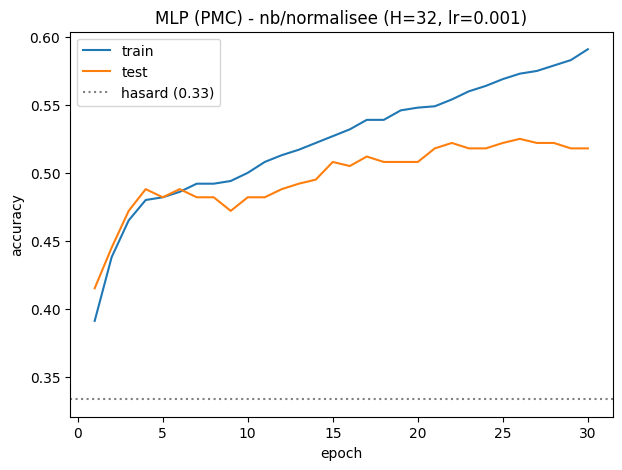

Accuracy finale : train=0.591  test=0.518


In [5]:
# courbe train vs test (pour voir le sur-apprentissage)
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))
plt.plot(epochs_liste, acc_train, label="train")
plt.plot(epochs_liste, acc_test, label="test")
plt.axhline(1/3, color="gray", linestyle=":", label="hasard (0.33)")
plt.xlabel("epoch")
plt.ylabel("accuracy")
plt.title(f"MLP (PMC) - {variante}/{normalisation} (H={H}, lr={lr})")
plt.legend()
plt.show()

print(f"Accuracy finale : train={acc_train[-1]:.3f}  test={acc_test[-1]:.3f}")

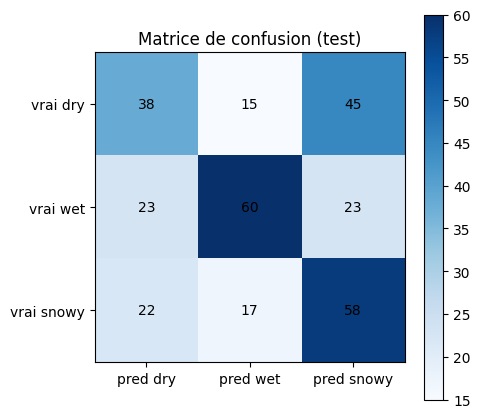

In [6]:
# matrice de confusion sur le test
import numpy as np

conf = np.array(confusion)
plt.figure(figsize=(5, 5))
plt.imshow(conf, cmap="Blues")
plt.colorbar()
plt.xticks([0, 1, 2], ["pred dry", "pred wet", "pred snowy"])
plt.yticks([0, 1, 2], ["vrai dry", "vrai wet", "vrai snowy"])
for i in range(3):
    for j in range(3):
        plt.text(j, i, conf[i][j], ha="center", va="center")
plt.title("Matrice de confusion (test)")
plt.show()

In [7]:
# precision / rappel / f1 par classe, calcules a la main depuis la confusion
noms_classes = ["dry", "wet", "snowy"]
for k in range(3):
    vp = confusion[k][k]
    fp = sum(confusion[i][k] for i in range(3) if i != k)
    fn = sum(confusion[k][j] for j in range(3) if j != k)
    precision = vp / (vp + fp) if (vp + fp) > 0 else 0.0
    rappel = vp / (vp + fn) if (vp + fn) > 0 else 0.0
    f1 = 2 * precision * rappel / (precision + rappel) if (precision + rappel) > 0 else 0.0
    print(f"{noms_classes[k]:6s} precision={precision:.3f} rappel={rappel:.3f} f1={f1:.3f}")


dry    precision=0.458 rappel=0.388 f1=0.420
wet    precision=0.652 rappel=0.566 f1=0.606
snowy  precision=0.460 rappel=0.598 f1=0.520


## Sauvegarde des poids

`mlp.c` ecrit ses poids entraines dans `models/mlp/poids_mlp.txt` a la fin de l'execution. On verifie ici que le fichier existe bien et qu'il contient ce qu'on attend.

In [7]:
# verification que la sauvegarde des poids a bien fonctionne
poids_path = racine / "models" / "mlp" / "poids_mlp.txt"

with open(poids_path) as f:
    ligne_dims = f.readline()

print("Fichier      :", poids_path)
print("Taille       :", poids_path.stat().st_size, "octets")
print("Dimensions (H d K_CLASSES) :", ligne_dims.strip())
print()
print("Format : ligne 1 = dimensions, puis W1 (H*d valeurs), b1 (H), W2 (K*H), b2 (K),")
print("chacun sur sa propre ligne, valeurs separees par des espaces.")

Fichier      : C:\Users\Amn\Desktop\PA SPRINT FINAL\models\mlp\poids_mlp.txt
Taille       : 4984630 octets
Dimensions (H d K_CLASSES) : 32 16384 3

Format : ligne 1 = dimensions, puis W1 (H*d valeurs), b1 (H), W2 (K*H), b2 (K),
chacun sur sa propre ligne, valeurs separees par des espaces.


## Comparaison des 6 variantes

Meme modele (memes H/epochs/lr/seed), applique aux 6 combinaisons rgb/nb/contours x normalisee/non_normalisee, comme le fait `notebook_linear.ipynb`.

In [8]:
# meme modele sur les 6 variantes, on compare l'acc test finale
def acc_test_finale(variante, normalisation):
    base = racine / "datasets" / "transformed" / variante / normalisation
    cmd = [
        str(chemin_exec),
        str(base / "X_train.f32bin"), str(base / "y_train.i32bin"),
        str(base / "X_test.f32bin"), str(base / "y_test.i32bin"),
        str(H), str(epochs), str(lr), str(seed),
    ]
    sortie_v = subprocess.check_output(cmd, text=True, cwd=str(racine))
    derniere = [l for l in sortie_v.strip().splitlines() if l.startswith("epoch ")][-1]
    return float(derniere.split()[5])

variantes = ["rgb", "nb", "contours"]
normalisations = ["normalisee", "non_normalisee"]
resultats = {}
for v in variantes:
    for n in normalisations:
        resultats[f"{v}/{n}"] = acc_test_finale(v, n)
        print(f"{v}/{n} : {resultats[f'{v}/{n}']:.3f}")

rgb/normalisee : 0.618
rgb/non_normalisee : 0.326
nb/normalisee : 0.518
nb/non_normalisee : 0.326
contours/normalisee : 0.478
contours/non_normalisee : 0.326


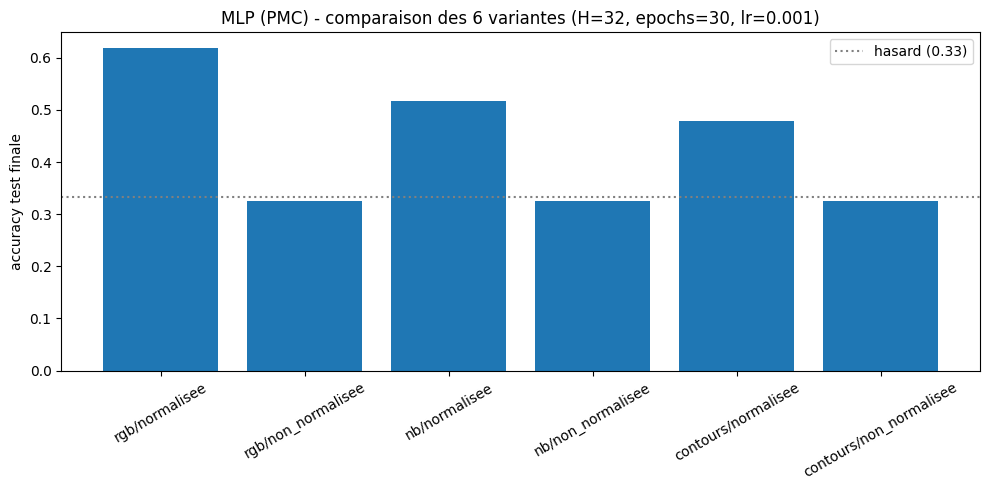

In [9]:
plt.figure(figsize=(10, 5))
plt.bar(resultats.keys(), resultats.values())
plt.axhline(1/3, color="gray", linestyle=":", label="hasard (0.33)")
plt.ylabel("accuracy test finale")
plt.title(f"MLP (PMC) - comparaison des 6 variantes (H={H}, epochs={epochs}, lr={lr})")
plt.xticks(rotation=30)
plt.legend()
plt.tight_layout()
plt.show()

## Comparaison MLP vs modele lineaire

Le modele lineaire de l'equipe plafonne a ~0.47 de test accuracy sur les vraies images (voir `models/lineaire/`). Comparaison directe avec le MLP de cette execution.

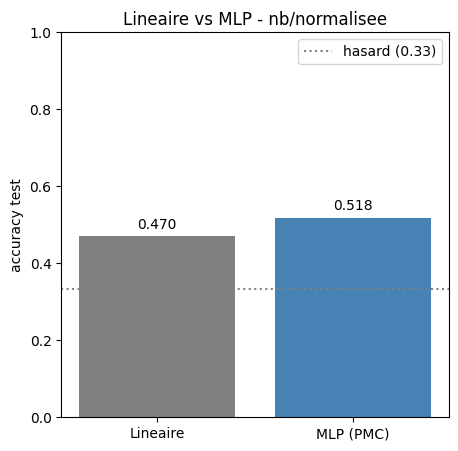

In [10]:
ACC_LINEAIRE = 0.47   # resultat documente du modele lineaire de l'equipe (models/lineaire/)

plt.figure(figsize=(5, 5))
plt.bar(["Lineaire", "MLP (PMC)"], [ACC_LINEAIRE, acc_test[-1]], color=["gray", "steelblue"])
plt.axhline(1/3, color="gray", linestyle=":", label="hasard (0.33)")
plt.ylabel("accuracy test")
plt.title(f"Lineaire vs MLP - {variante}/{normalisation}")
plt.ylim(0, 1)
for i, v in enumerate([ACC_LINEAIRE, acc_test[-1]]):
    plt.text(i, v + 0.02, f"{v:.3f}", ha="center")
plt.legend()
plt.show()